In [30]:
import torch
import torch.nn.functional as F
import torch.nn as nn
# import torch.optim as optim
# import torch_optimizer as optim
import torch.nn.init as init
import adabound
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split

from sys import stdout
from tqdm import tqdm
from tqdm import trange
import seaborn as sns

import time
from datetime import datetime as dt

In [32]:
df = pd.read_csv('https://raw.githubusercontent.com/zorocrit/Control_Nuclear_Spins/master/C13spin/testdata.csv?token=GHSAT0AAAAAAB5HMDTBZEU4QOG5J6PCH73IZBDTH3Q')
# df

In [33]:
# y = df[['x', 'N', 'z']]
# # y

y = df[['Ztau', 'ZN']]
y

,Ztau,ZN
0,0.176380,1.0
1,0.625249,22.0
2,1.129403,1.0
3,0.059788,1.0
4,0.197018,4.0
...,...,...
11824,0.115000,1.0
11825,1.100000,19.0
11826,0.842072,1.0
11827,0.478750,1.0


In [34]:
X = df[['Al', 'Ap', 'Xtau', "XN"]]
# X

In [35]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.10, random_state=100)

In [36]:
Xdata = list(np.array(X_train.values.tolist()))
print(Xdata.__len__())

10646


In [37]:
ydata = list(np.array(y_train.values.tolist()))
# print(ydata)

In [39]:
torch.manual_seed(1)

In [40]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for reproducibility
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)
print(device)

cuda


In [41]:
x = torch.FloatTensor(Xdata).to(device)
y = torch.FloatTensor(ydata).to(device)

In [42]:
num_data = Xdata.__len__()

num_epoch = 2000000

In [43]:
from sys import stdout


model = nn.Sequential(

    nn.Linear(4,400),

    nn.ReLU(),

    nn.Linear(400,400),

    nn.ReLU(),

    nn.Linear(400,400),

    nn.ReLU(),
    
    nn.Linear(400,400),

    nn.ReLU(),
    
    nn.Linear(400,400),

    nn.ReLU(),
        
    nn.Linear(400,400),

    nn.ReLU(),
    
    nn.Linear(400,400),

    nn.ReLU(),

    nn.Linear(400,2)

).to(device)

#ReLU라는 Activation Function을 사용하여, 4개의 Linear Layer로 모델 구현

# Input layer에 1개씩 데이터가 들어가므로 nn.Linear(1,2)이며, 최종적으로 1개의 값이 나와야하기에 Output Layer는 nn.Linear(4,1)

 

loss_func = nn.L1Loss().to(device)

# optimizer = optim.SGD(model.parameters(),lr = 0.0002)

# optimizer = adabound.AdaBound(model.parameters(), lr=0.935 * 1e-4, final_lr=0.05758)  #Loss: 0.0537

# optimizer = adabound.AdaBound(model.parameters(), lr=0.435 * 1e-3, final_lr=0.05558)

optimizer = adabound.AdaBound(model.parameters(), lr=0.935 * 1e-4, final_lr=0.04958)  #Loss: 0.0537

loss_array = []

minloss = 10

for i in tqdm(range(num_epoch)) : 

    optimizer.zero_grad()

    output = model(x)

    loss = loss_func(output,y)

    loss.backward()

    optimizer.step()

    if(loss < minloss):
       minloss = loss

    loss_array.append(loss)
    if(i == 1):
      stdout.write("Minimum loss: " + str(minloss))
    if(i%100000 == 0 and i != 0):
      # print("Case "+ str(i) + ", Loss: " + str(loss.data))
      stdout.write("Minimum loss: " + str(minloss))

    if i == num_epoch - 1:

        print(loss.data)

        param_list = list(model.parameters())

        #최종 학습된 마지막 결과물의 Parameter 저장

        print(param_list)

loss_array = torch.tensor(loss_array)

loss_array.detach().numpy()

plt.plot(loss_array)

plt.show()

#Loss(y_predicted - y_real)값이 어떻게 변하는지 그래프로 도식화

  0%|          | 12/2000000 [00:00<9:16:37, 59.88it/s]

Minimum loss: tensor(2.6634, device='cuda:0', grad_fn=<L1LossBackward0>)

  0%|          | 1102/2000000 [00:08<4:25:36, 125.43it/s]


KeyboardInterrupt: 

In [75]:
# # 임의의 입력 [73, 80, 75]를 선언
# new_var =  torch.FloatTensor([[4.493041, 0.5427]]).to(device)
# # 입력한 값 [73, 80, 75]에 대해서 예측값 y를 리턴받아서 pred_y에 저장
# pred_y = model(new_var) 
# print("훈련 후 예측값 :", pred_y)  

훈련 후 예측값 : tensor([[ 3.4226, 16.2565,  2.0645, 12.0586]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


In [22]:
from datetime import datetime as dt 
date = dt.now()

printdate = date.strftime('%Y%m%d_%H%M%S')
print(date)

torch.save(model.state_dict(), "model_" + printdate + ".h5")

2023-03-28 13:56:38.126689


In [ ]:
# model = nn.Sequential(

#     nn.Linear(2,400),

#     nn.ReLU(),

#     nn.Linear(400,400),

#     nn.ReLU(),

#     nn.Linear(400,400),

#     nn.ReLU(),
    
#     nn.Linear(400,400),

#     nn.ReLU(),
    
#     # nn.Linear(400,400),

#     # nn.ReLU(),
        
#     # nn.Linear(400,400),

#     # nn.ReLU(),
    
#     # nn.Linear(400,400),

#     # nn.ReLU(),

#     nn.Linear(400,4)

# ).to(device)

# model.load_state_dict("CNN_Model_20230307_144034.h5")

In [23]:
X_input = list(np.array(X_valid.values.tolist()))
new_var =  torch.FloatTensor(X_input).to(device)
y_input = model(new_var)
y_input = np.array(y_input.tolist())
y_input

array([[4.85149980e-01, 3.95297861e+00],
       [1.58414543e-02, 1.82803669e+01],
       [4.10409570e-01, 1.01882076e+00],
       ...,
       [9.19202209e-01, 9.79220629e-01],
       [4.92165387e-02, 4.06799793e+00],
       [1.02084863e+00, 1.52123528e+01]])

In [24]:
y_output = np.array(y_valid.values.tolist())
y_output

array([[ 0.51117575,  7.        ],
       [ 0.05223668, 10.        ],
       [ 0.42125   ,  1.        ],
       ...,
       [ 0.3775    , 22.        ],
       [ 0.0970125 ,  4.        ],
       [ 0.98770139,  7.        ]])

In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# MAE
print("Z tau MAE: " + str(mean_absolute_error(y_input[:, 0], y_output[:, 0])))
print("Z N MAE: " + str(mean_absolute_error(y_input[:, 1], y_output[:, 1])))
# print("Z tau MAE: " + str(mean_absolute_error(y_input[:, 2], y_output[:, 2])))
# print("Z N MAE: " + str(mean_absolute_error(y_input[:, 3], y_output[:, 3])))

print(' ')
#MSE
print("Z tau MSE: " + str(mean_squared_error(y_input[:, 0], y_output[:, 0])))
print("Z N MSE: " + str(mean_squared_error(y_input[:, 1], y_output[:, 1])))
# print("Z tau MSE: " + str(mean_squared_error(y_input[:, 2], y_output[:, 2])))
# print("Z N MSE: " + str(mean_squared_error(y_input[:, 3], y_output[:, 3])))

print(' ')
#r2
print("Z tau r2: " + str(r2_score(y_input[:, 0], y_output[:, 0])))
print("Z N r2: " + str(r2_score(y_input[:, 1], y_output[:, 1])))
# print("Z tau r2: " + str(r2_score(y_input[:, 2], y_output[:, 2])))
# print("Z N r2: " + str(r2_score(y_input[:, 3], y_output[:, 3])))

Z tau MAE: 0.2096989974670888
Z N MAE: 2.8585514698902914
 
Z tau MSE: 0.13021071768002082
Z N MSE: 29.032404590298945
 
Z tau r2: 0.23631741508277326
Z N r2: -0.7085179100669663


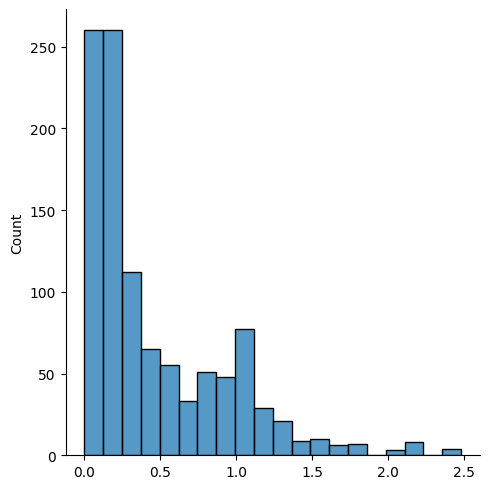

In [27]:
sns.displot(y_output[:, 0])

In [17]:
# Al = 2*math.pi*0.3
# Ap = 2*math.pi*0.3

number = 81

# Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
# Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term

Alarr = X_valid[['Al']]
Aparr = X_valid[['Ap']]
Alarr = list(np.array(Alarr))
Aparr = list(np.array(Aparr))



Al = Alarr[number]
Ap = Aparr[number]

Al = float(Al)
Ap = float(Ap)
AAin = torch.FloatTensor([[Al, Ap]]).to(device)

AA_predict = model(AAin)

AAA_predict = np.array(AA_predict.tolist())

xt = y_valid['Xtau']
xn = y_valid['XN']
zt = y_valid['Ztau']
zn = y_valid['ZN']

xt = list(np.array(xt))
xn = list(np.array(xn))
zt = list(np.array(zt))
zn = list(np.array(zn))


AAdata = pd.DataFrame(AAA_predict, columns= ['Xtau', 'XN', 'Ztau', 'ZN'])

tau = AAdata['Xtau']

bounds = [(0.85*tau,1.15*tau),(1.0,25.0),(0.00000000000000000001*tau,0.5*tau),(1.0,25.0)] #boundary
print(AAdata)
print(str(xt[number]) + " " + str(xn[number]) + " " + str(zt[number]) + " " + str(zn[number]) + " ")


       Xtau         XN      Ztau        ZN
0  0.499163  10.141086  0.085619  2.008855
0.485 10.0 0.0909375 1.0 


In [18]:
#3/20(월)
# initialization system
# 이 코드는 13C의 nuclear spin을 초기화 시키는 코드입니다.,·
# 각 gate의 파라미터를 찾아서 초기화 시킵니다.
# initial:mixed state, target : up state
from toqito.channels import partial_trace
from qutip import *
from PIL import Image
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from scipy import linalg
import math
import matplotlib.pyplot as plt
from scipy import optimize
import random
from math import *
import pandas as pd
import time
from datetime import datetime as dt                         # 시간을 출력하기 위한 라이브러리  
import random
from mpl_toolkits.mplot3d import Axes3D
from sys import stdout
from tqdm import tqdm
from tqdm import trange
from scipy.linalg import fractional_matrix_power

totalstart = time.time() #시작 시간 저장

#Generating gate function
def UO(B1,B2,a,D1,D2):
    i   = 1j
    gamma = 2*pi*2.8
    D     = 2870
    UA = [[(B2**2+B1**2*cos(a))/(B1**2+B2**2), -i*B1*(e**(-i*D1))*sin(a)/sqrt(B1**2+B2**2), ((-1+cos(a))*B1*B2*(e**(-i*(D1-D2))))/(B1**2+B2**2)],
            [-i*B1*(e**(i*D1))*sin(a)/sqrt(B1**2+B2**2), cos(a), -i*B2*(e**(i*D2))*sin(a)/sqrt(B1**2+B2**2)],
            [((-1+cos(a))*B1*B2*e**(i*(D1-D2)))/(B1**2+B2**2), -i*B2*(e**(-i*D2))*sin(a)/sqrt(B1**2+B2**2), (B1**2+B2**2*cos(a))/(B1**2+B2**2)]]
    return UA

## Define dimension, pauli matrices
i   = 1j #1j
sx  = 1/sqrt(2)*np.array([[0, 1, 0],[1, 0, 1], [0, 1, 0]])
sy  = 1/sqrt(2)/i*np.array([[0, 1, 0], [-1, 0, 1],[0, -1, 0]])
sz  = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
#sz  = [1, 0, 0; 0, -1, 0; 0, 0, 0]
I   = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

# Rotation matrix projected into 2 level system
Sxp  = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]])
Sxm  = np.array([[0, 0, 0], [0, 0, 1], [0, 1, 0]])
Syp  = 1/i*np.array([[0, 1, 0], [-1, 0, 0], [0, 0, 0]])
Sym  = 1/i*np.array([[0, 0, 0], [0, 0, 1], [0, -1, 0]])
Szp  = np.array([[1, 0, 0], [0, -1, 0], [0, 0, 0]])

#Gellman matrix
Sx  = np.array([[0, 0, 1],[0, 0, 0], [1, 0, 0]])
Sy  = np.array([[0, 0, -i],[0, 0, 0], [i, 0, 0]])
Sz  = np.array([[1, 0, 0],[0, 0, 0], [0, 0, -1]])

# Pauli basis for 13C nuclear spin
Ix  = 1/2*np.array([[0, 0, 1], [0, 0, 0], [1, 0, 0]])   
Iy  = 1/2/i*np.array([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
Iz  = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
 

## Define sweep parameters
Sweep = 1001
N = Sweep
B = 403 #[G] magnetic field

T = 5; # sweep tau [us]
t = np.linspace(0,T,N)
n = 32; # number of pi pulses

## Define gate operations
# Single Q ms=+1
U090xp = UO(1,0,pi/4,0,0)
U090xmp = UO(1,0,-pi/4,0,0)
U090yp = UO(1,0,pi/4,pi/2,0)
U090ymp = UO(1,0,-pi/4,pi/2,0)
U180xp = UO(1,0,pi/2,0,0)
U180xmp = UO(1,0,-pi/2,0,0)

#Single Q ms=-1
U090xm = UO(0,1,pi/4,0,0)
U090xmm = UO(0,1,-pi/4,0,0)
U180xm = UO(0,1,pi/2,0,0)
U180xmm = UO(0,1,pi/2,0,0)

# Define initial state of the system

irho_p = np.array([[1,0,0],[0,0,0],[0,0,0]]) #[0,0,0;0,0,0]

irho_m = np.array([[0,0,0],[0,0,0],[0,0,1]]) #[0,0,0;0,0,1]

irho_z = np.array([[0,0,0],[0,1,0],[0,0,0]]) #[0,1,0;0,0,0]

irho_mix = np.array([[1/2,0,0],[0,1/2,0],[0,0,0]]) #[1/2,0,0;0,1/2,0;0,0,0]

irho_Z = np.array([[0,0,0],[0,0,0],[0,0,1]]) #target state

irho_MIX = np.array([[1/2,0,0],[0,0,0],[0,0,1/2]])

irho = np.kron(irho_z,irho_MIX) #initial state
trace = [1, 1, 0, 100, 100, 1000, 100] # trace of the X, Y, Z, and total density matrices
vvv = [0, 0, 0, 0] 
bbb = [0, 0, 0, 0]
normalxyz = [0, 0, 0]
    
date = dt.now()
printdate = date.strftime('%Y%m%d_%H%M%S')
print(date)

def state_fidelity(rho_1, rho_2): #fidelity
        if np.shape(rho_1) != np.shape(rho_2):
            print("Dimensions of two states do not match.")
            return 0
        else:
            sqrt_rho_1 = fractional_matrix_power(rho_1, 1 / 2)
            fidelity = np.trace(fractional_matrix_power(sqrt_rho_1 @ rho_2 @ sqrt_rho_1, 1 / 2)) ** 2
            return np.real(fidelity)

def integer_constraint(x):
    x_int = np.round(x).astype(int)
    x_int[1] = x[1]
    x_int[3] = x[3]
    return x - x_int


def problem(vari): 
        #for e Ry(pi/2)
        rho1 = np.kron(U090yp,I)@irho@(np.kron(U090yp,I).conj().T)                              # Ry 90도

        #for N Rx(pi/2)
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
        rho2=U_e2@rho1@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
            rho2 = U_e@np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho3 = U_e2 @ np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        #for e Rx(pi/2)
        rho4 = np.kron(U090xp,I)@rho3@(np.kron(U090xp,I).conj().T)                              # Rx 90도

        #for N Rz(pi/2) //이부분이 Z pulse를 다루고 있다면 N을 따로 분리해야하나?>
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E*vari[2]/2)@U_H)                                   # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E*vari[2])@U_H)                                      # for tau/2
        rho5=U_e2@rho4@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[3])):                                                # N과 tau를 N개 생성
            rho5 = U_e@np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho6 = U_e2 @ np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        #for N Rx(pi/2)
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
        rho7=U_e2@rho6@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
            rho7 = U_e@np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho8 = U_e2 @ np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        # projection&trace
        xob = (np.trace(Sxp@partial_trace(rho8,2))).real # for e spin
        yob = (np.trace(Syp@partial_trace(rho8,2))).real 
        zob = (np.trace(Szp@partial_trace(rho8,2))).real

        xx = (np.trace(Ix@partial_trace(rho8,1))).real # for N spin
        yy = (np.trace(Iy@partial_trace(rho8,1))).real
        zz = (np.trace(Iz@partial_trace(rho8,1))).real
        
        cost = 1 - state_fidelity(irho_Z, partial_trace(rho8, 1))

        cost2 = 2 * vari[0] * vari[1] + vari[2] * vari[3]
        
        if cost < 0.01:
             if (cost2<trace[5]):
                trace[0] = xx
                trace[1] = yy
                trace[2] = zz
                trace[4] = cost
                trace[5] = cost2
                vvv[0] = vari[0]
                vvv[1] = vari[1]
                vvv[2] = vari[2]
                vvv[3] = vari[3]
        if(cost < trace[6]):
            trace[6] = cost
            normalxyz[0] = xx
            normalxyz[1] = yy
            normalxyz[2] = zz
            
            bbb[0] = vari[0]
            bbb[1] = vari[1]
            bbb[2] = vari[2]
            bbb[3] = vari[3]
        print("cost: " + str(cost) + "x: " + str(xx) + "y: " + str(yy) + "z: " + str(zz) + "N: " + str(vari[1]) + "tau: " + str(vari[0]) + "N2: " + str(vari[3]) + "tau2: " + str(vari[2]))
        return cost
        
aa = []
cc = []
dd = []
count = 1
tot_sum = 0
tolN = 1e-15

for ccc in tqdm(range(1)): # range 번의 실험을 진행한다.
    trace = [1, 1, 0, 100, 100, 1000, 100]
    vvv = [0, 0, 0, 0]
    bbb = [0, 0, 0, 0]
    normalxyz = [0, 0, 0]
    start = time.time()
    #for making 13C nuclear random dataset
    gammaN = 2*pi*1.071e-3 #[MHz/G]
    Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
    Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term

    #Initialization
    rho_0 = (np.kron(U090xp,I))@irho@((np.kron(U090xp,I)).conj().T) # superposition state on NV

    Sa= []

    ham = Al*np.kron(sz,Iz) + Ap*np.kron(sz,Ix) + B*gammaN*np.kron(I,Iz) # Hamiltonian
    eigvals = np.linalg.eigh(ham)[0]            # diagonalizing the Hamiltonian 여기서부터 문제 
    eigvecs = -1*np.linalg.eigh(ham)[1]         # eigenvectors
    E = np.diag(eigvals)                        # exponent of eigenvalues
    U_H= eigvecs.conj().T                       # unitary matrix formed by eigenvectors
    

    for p in range(1): # 1번의 실험을 진행한다.(지역 최적화 알고리즘을 사용할 경우에 수정한다.)
        vari= AAdata
        bounds = [(0.85*tau,1.15*tau),(1.0,25.0),(0.00000000000000000001*tau,0.5*tau),(1.0,25.0)] #boundary
        
        # res4 = optimize.shgo(problem,bounds=bounds,iters=5,options={'xtol':1e-15,'ftol':1e-17}) #SHGO method
        res4 = optimize.minimize(problem, AAdata, bounds=bounds ,method='Nelder-Mead',options={'xtol':tolN,'ftol':tolN, 'maxiter': 2000, 'maxfev': 2000}) #Nelder-Mead method
        res4['x'][1] = math.trunc(res4['x'][1]) #rounding
        res4['x'][3] = math.trunc(res4['x'][3]) #rounding

        if(np.abs(res4['fun']) < 0.01 and trace[0] != 1): #fidelity가 0.05보다 작으면 성공
            dd.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
            cc.append([Al, Ap, trace[4], vvv[0], vvv[1], vvv[2], vvv[3], trace[0], trace[1], trace[2], res4["nfev"]])
            end = time.time()
            final = end - start
            count = count + 1
        else:
            aa.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
            end = time.time()
            final = end - start
            count = count + 1


# 결과들을 list에 저장하여 csv파일로 저장


print('success')

totalend = time.time()
print(totalend - totalstart)

print(dd)
print(cc)
print(aa)
# # %%

2023-03-27 14:24:17.815136


  0%|          | 0/1 [00:00<?, ?it/s]

cost: 0.3091899446352384x: 0.0020267973299452416y: 0.0011580417799298554z: -0.3816201107295365N: 10.141085624694824tau: 5.340707511102648N2: 2.0088553428649902tau2: 0.08561861515045166
cost: 0.5007616757258038x: 4.959210441566209e-05y: -1.2725505452967564e-05z: 0.0015233514515922142N: 10.141085624694824tau: 5.607742886657781N2: 2.0088553428649902tau2: 0.08561861515045166
cost: 0.3091899446352384x: 0.0020267973299452416y: 0.0011580417799298554z: -0.3816201107295365N: 10.648139905929566tau: 5.340707511102648N2: 2.0088553428649902tau2: 0.08561861515045166
cost: 0.2683443838972577x: 0.002603642341632746y: 0.0014309538608671818z: -0.4633112322054982N: 10.141085624694824tau: 5.340707511102648N2: 2.0088553428649902tau2: 0.08989954590797425
cost: 0.3091899446352384x: 0.0020267973299452416y: 0.0011580417799298554z: -0.3816201107295365N: 10.141085624694824tau: 5.340707511102648N2: 2.1092981100082397tau2: 0.08561861515045166
cost: 0.28799123658189985x: 0.0023163764592139605y: 0.001297972719599902

C:\Users\KIST3\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:225: OptimizeWarning: Initial guess is not within the specified bounds


cost: 0.21294040673697556x: 0.003885113227041506y: 0.003604519910416888z: -0.5741191865260615N: 9.827472675543689tau: 5.340707511102648N2: 2.136808908198873tau2: 0.09278481067176472
cost: 0.19711015915977714x: 0.005259299457696119y: 0.004197337679936221z: -0.605779681680459N: 9.622387106807587tau: 5.340707511102648N2: 2.1854348187389405tau2: 0.10288336798867026
cost: 0.20258177161176283x: 0.005646268211794821y: 0.004285326773178728z: -0.5948364567764867N: 9.080798572882848tau: 5.340707511102648N2: 2.1618345387423687tau2: 0.1061845041157995
cost: 0.2764562210382526x: 0.006689380507913453y: 0.006169445072336632z: -0.4470875579235066N: 8.691608338229525tau: 5.340707511102648N2: 2.1561718355883386tau2: 0.10941125502106397
cost: 0.19775936470119748x: 0.0047152653712187395y: 0.004007347910152944z: -0.6044812705976164N: 9.5514331828766tau: 5.340707511102648N2: 2.1507373992591283tau2: 0.09867796966746599
cost: 0.20660134552625586x: 0.004143186797231302y: 0.0037426461836573832z: -0.586797308947

100%|██████████| 1/1 [00:04<00:00,  4.84s/it]

cost: 0.19633959110846477x: 0.005034769709107066y: 0.004127184065517105z: -0.6073208177830816N: 9.474485972417568tau: 5.340707511102648N2: 2.139584370398034tau2: 0.10109956571673362
cost: 0.19633959110846455x: 0.005034769709107205y: 0.004127184065517084z: -0.6073208177830818N: 9.474485972417567tau: 5.340707511102648N2: 2.139584370398034tau2: 0.10109956571673363
cost: 0.19633959110846455x: 0.005034769709107205y: 0.004127184065517084z: -0.6073208177830818N: 9.474485972417568tau: 5.340707511102648N2: 2.139584370398034tau2: 0.10109956571673363
cost: 0.19633959110846477x: 0.005034769709107066y: 0.004127184065517105z: -0.6073208177830816N: 9.474485972417568tau: 5.340707511102648N2: 2.139584370398034tau2: 0.10109956571673362
cost: 0.19633959110846477x: 0.005034769709107066y: 0.004127184065517105z: -0.6073208177830816N: 9.474485972417568tau: 5.340707511102648N2: 2.139584370398034tau2: 0.10109956571673362
cost: 0.19633959110846477x: 0.005034769709107378y: 0.00412718406551715z: -0.60732081778308